<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
!pip install -q google-genai pillow

In [60]:
from IPython.display import Image, Markdown

def print_response(response):
    print(f"Response id: {response.response_id}")
    print(f"Input tokens: {response.usage_metadata.prompt_token_count}; Output tokens: {response.usage_metadata.candidates_token_count}")

    for part in response.parts:
        if part.text is not None:
            if part.thought:
                markdown_content = f"<br/> <i>[Thinking...]</i> <br/> <i>{part.text}</i> <br/>"
            else:
                markdown_content = f"<br/> <strong>Final response:</strong> <br/> {part.text} <br/>"
            display(Markdown(markdown_content))

        if part.inline_data is not None:
            format = part.inline_data.mime_type.split('/')[1]
            display(Image(data=part.inline_data.data, format = format))

In [41]:
from google import genai
from google.genai import types
from google.colab import userdata
import requests
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, display
from io import BytesIO

api_key = userdata.get("GEMINI_API_KEY")
pollinations_api_key = userdata.get("POLI_API_KEY")
client = genai.Client(api_key = api_key)

## Text to Image

In [69]:
generate_portrait_prompt = (
    "A photorealistic portrait of a 24-year-old software developer from Italy, "
    "wearing glasses and sitting in a cozy home office. "
    "Two monitors displaying code are on the desk. "
    "Warm sunlight streams through a large open window. "
    "Outside is a beautiful garden with fruit trees and vegetables. "
    "Ultra-realistic, natural skin texture, shallow depth of field, "
    "soft cinematic lighting, highly detailed, professional photography, "
    "85mm portrait lens, HDR. "
    "Vertical portrait orientation."
)

url = (
    f"https://gen.pollinations.ai/image/{quote(generate_portrait_prompt)}"
    f"?model=flux&width=768&height=1024"
)


In [70]:
response = requests.get(
    url,
    headers={
        "Authorization": f"Bearer {pollinations_api_key}"
    },
    timeout=180,
)

In [71]:
print("Status:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))

Status: 200
Content-Type: image/jpeg


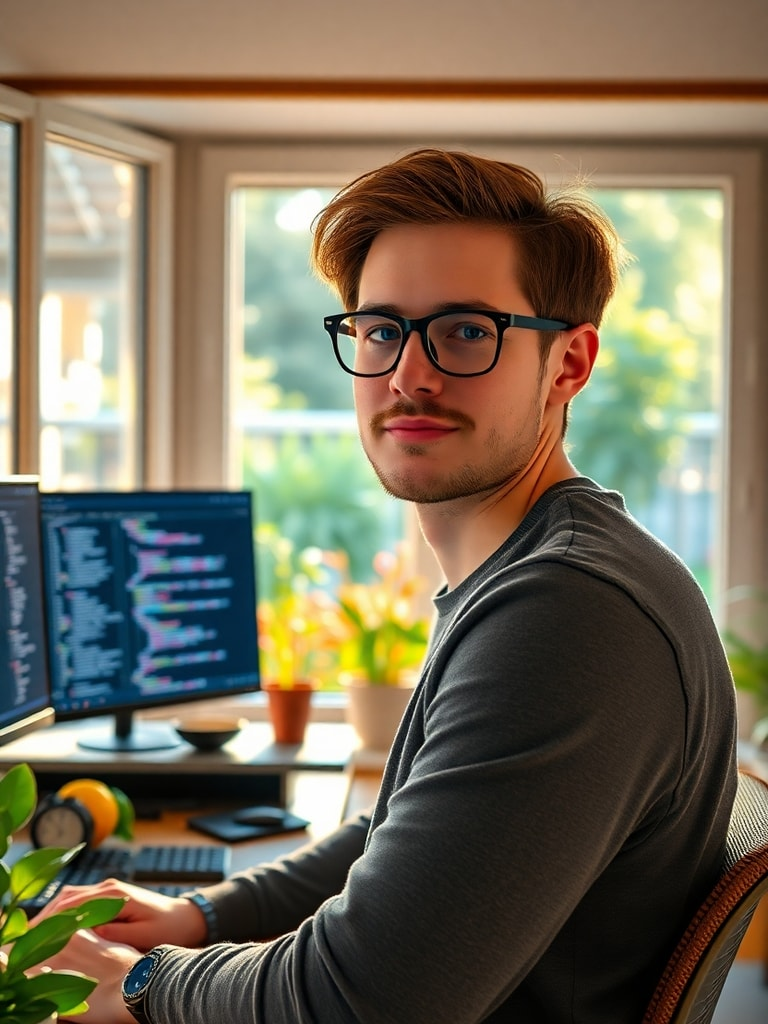

In [72]:
if response.ok and response.headers.get("content-type", "").startswith("image/"):
    image = PILImage.open(BytesIO(response.content))
    display(image)
    image.save("generated_portrait.png")
else:
    print(response.text[:1000])

In [73]:
generte_portrait_response = client.models.generate_content(
    model = "gemini-3.1-flash-image-preview",
    contents = [generate_portrait_prompt],
    config = types.GenerateContentConfig(
        thinking_config = types.ThinkingConfig(
            include_thoughts = True,
            thinking_level = "high"
        ),
        image_config = types.ImageConfig(
            aspect_ratio = "16:9",
            image_size = '512px'
        )
    )
)

In [74]:
generte_portrait_response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text="""**Crafting the Portrait**

I'm now focusing on the composition, ensuring Lorenzo is placed slightly right of center, gazing directly at the viewer with a welcoming expression. The large window and lush garden are prominent in the background, with the monitors displaying code to his left. I'm prioritizing realistic skin details, like pores and beard growth, and the light reflecting off his glasses. The background is being rendered with a smooth bokeh effect, emphasizing the garden's vibrant colors and sunlight, and the shallow depth of field.


""",
            thought=True
          ),
          Part(
            inline_data=Blob(
              data=<... Max depth ...>,
              mime_type=<... Max depth ...>
            ),
            thought=True
          ),
          Part(
            text="""**Adjusting View 

Response id: ovFbave5Hq3UjMcP9uO-yAc
Input tokens: 94; Output tokens: 575


<br/> <i>[Thinking...]</i> <br/> <i>**Crafting the Portrait**

I'm now focusing on the composition, ensuring Lorenzo is placed slightly right of center, gazing directly at the viewer with a welcoming expression. The large window and lush garden are prominent in the background, with the monitors displaying code to his left. I'm prioritizing realistic skin details, like pores and beard growth, and the light reflecting off his glasses. The background is being rendered with a smooth bokeh effect, emphasizing the garden's vibrant colors and sunlight, and the shallow depth of field.


</i> <br/>

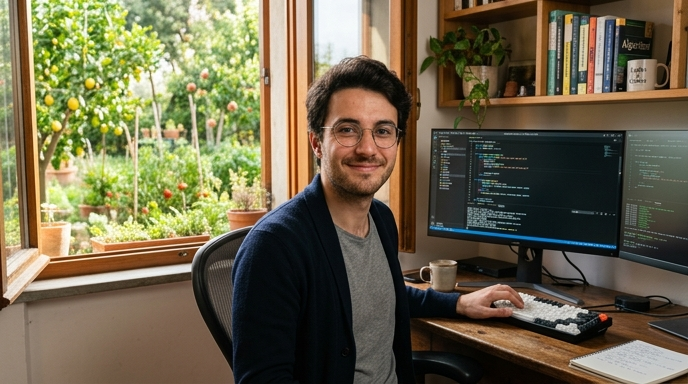

<br/> <i>[Thinking...]</i> <br/> <i>**Adjusting View and Format**

I'm focused on rectifying the aspect ratio, transforming the scene into a vertical portrait to align with the prompt. The core challenge is achieving this while maintaining the requested character details. I'm expanding the view to show more of the desk and bookshelves, adding a small succulent, Italian books, and a woven rug to provide more context. The goal is to retain consistency while increasing visual depth.


</i> <br/>

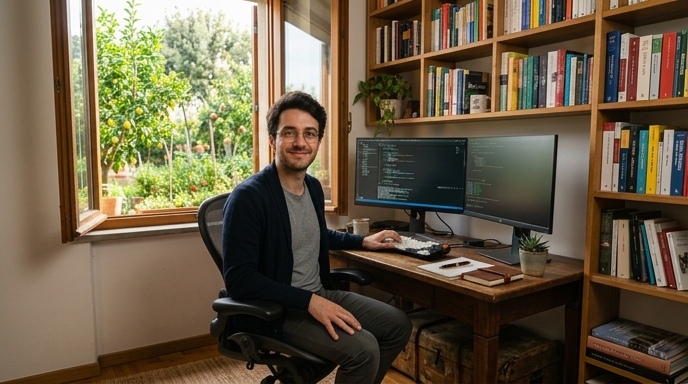

<br/> <i>[Thinking...]</i> <br/> <i>**Analyzing Current Output**

I've examined the latest iteration. The orientation problem is resolved; the image is now vertical. The visual elements align with the specifications: subject, glasses, coding setup, and garden. I consider this output ready for user delivery.


</i> <br/>

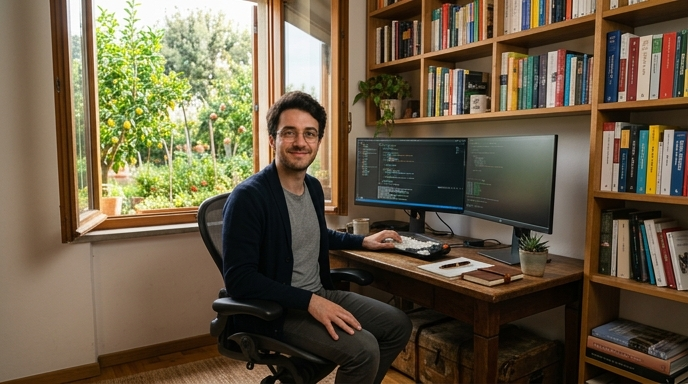

In [75]:
print_response(generte_portrait_response)

## Text-Image to Image

In [76]:
edit_prompt = (
    "Edit the portrait. "
    "The software developer is now looking dreamily out the window with a soft, absent-minded gaze, "
    "slightly turned away from the computer. "
    "He is holding a fork in one hand, mid-twirl, and eating a plate of pasta Bolognese placed on his desk next to the keyboard. "
    "His expression is wistful and relaxed, as if lost in thought while enjoying his meal. "
    "Keep everything else exactly the same: the person's appearance, the lighting, the home office setting, "
    "the garden outside the window, the warm color palette, and the photorealistic style."
)

In [77]:
edit_response = client.models.generate_content(
    model = "gemini-3.1-flash-image-preview",
    contents = [
        types.Content(role = "user", parts= [types.Part(text = generate_portrait_prompt)]), # първоначално обръщение
        types.Content(role = "model", parts = generte_portrait_response.parts), # отговора на нанобанана, който ни върна
        types.Content(role="user", parts = [types.Part(text = edit_prompt)]) # и сега искаме да включим в историята нашият edit_prompt
    ],
    config = types.GenerateContentConfig(
        response_modalities = ["Image"],
        thinking_config = types.ThinkingConfig(
            include_thoughts = False,
            thinking_level = "minimal"
        ),
        image_config = types.ImageConfig(
            aspect_ratio = "16:9",
            image_size = '512px'
        )
    )
)

Response id: 0_Fbas2MB--OjMcP2Ovf-Qc
Input tokens: 1238; Output tokens: 1512


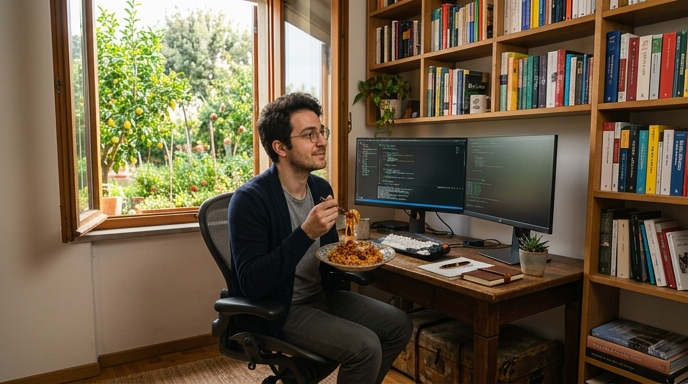

In [78]:
print_response(edit_response)

In [84]:
def save_last_image(response, path_to_file):
    last_image_part = next(p for p in reversed(response.parts) if p.inline_data is not None)
    last_image_part.as_image().save(path_to_file)

In [85]:
save_last_image(edit_response, "/content/software_developer.jpeg")

## Image to Text

In [86]:
analyze_image_prompt = """
                       Analyze the provided image in detail. Describe:
                       - Every visible object, includeing its position, size, color, and condition
                       - Relationships between objects (proximity, overlaps, interactions)
                       - Lighting, color palette, and overall atmosphere
                       - Any text, symbols, or notable details

                       Be thorough and specific. Do not omit minor or background elements.
                       """

In [92]:
from PIL import Image

analyze_response = client.models.generate_content(
    model = "gemini-3-flash-preview",
    contents = [
        analyze_image_prompt,
        Image.open("/content/software_developer.jpeg")
    ],
    config = types.GenerateContentConfig(
        response_modalities = ["text"]
    )
)

In [93]:
print_response(analyze_response)

Response id: JfVbaszQO_aK-sAPnpDhgAU
Input tokens: 1182; Output tokens: 1231


<br/> <strong>Final response:</strong> <br/> This image depicts a man eating a meal while working in a well-lit home office or study. 

### **Objects: Position, Size, Color, and Condition**

*   **The Man:** Centrally positioned, slightly to the left of the desk. He is of medium build with dark, curly hair, glasses, and short facial hair. He wears a dark blue cardigan over a gray t-shirt and dark gray trousers. He is in the middle of eating, looking towards the computer monitors.
*   **The Desk:** A rectangular, dark-stained wooden desk positioned against the right wall. It appears sturdy and well-used.
*   **Monitors:** Two widescreen flat-panel monitors sit on the desk. They are black with thin bezels. The left monitor displays lines of computer code in an Integrated Development Environment (IDE) with a dark theme. The right monitor shows more text/code in a terminal-like window. Both are in excellent condition.
*   **Keyboard and Mouse:** A mechanical keyboard with white and light-gray keys and a black frame sits on the desk in front of the left monitor. A black computer mouse is positioned to its right.
*   **Office Chair:** A high-end black ergonomic mesh office chair (resembling a Herman Miller Aeron). It is positioned facing the desk but angled slightly toward the viewer.
*   **The Meal:** The man holds a shallow ceramic bowl with a blue and white pattern, filled with pasta (possibly rotini or fusilli) topped with a dark red meat sauce (Bolognese). He holds a silver-colored fork with a swirl of pasta on it near his face.
*   **Desk Accessories:** 
    *   A small white notepad or sketchbook sits on the right side of the desk.
    *   A dark-colored fountain pen lies on the notepad.
    *   A small, brown leather-bound notebook/journal is next to the notepad.
    *   A small, textured gray/brown pot containing a green succulent sits near the right monitor.
*   **Bookshelves:** Large, light-brown wooden built-in bookshelves cover the upper half of the right wall. They are filled with a dense collection of books of varying sizes.
*   **Books:** Dozens of books are visible. Spine colors include red, bright blue, yellow, green, white, and black. While the titles are not legible, the sheer volume suggests an academic or professional collection. 
*   **Potted Plants:** 
    *   A small green trailing plant (likely a Pothos) in a white pot sits on one of the middle bookshelves.
    *   The succulent on the desk mentioned above.
*   **The Window:** A large, double-paned window with a light-brown wooden frame is located on the left wall. The left pane is swung open inward.
*   **The Garden/View:** Visible through the window is a lush, sunny garden. A prominent tree with bright yellow fruit (likely lemons) is in the foreground. Background elements include various green bushes and other trees under bright, natural daylight.
*   **Trunk:** Underneath the desk, on the floor, is a large, vintage-style trunk or suitcase. It is a weathered tan/light brown color with dark metal hardware.
*   **Floor and Rug:** The floor is made of light-toned wood planks. A neutral-colored, low-pile woven area rug is partially visible under the office chair.
*   **Walls:** The walls are painted a clean, off-white or cream color.

### **Relationships and Interactions**

*   **Proximity:** The man is closely seated at the desk, indicating a work-from-home scenario. The bookshelves are within arm's reach of his workspace.
*   **Interactions:** The man is actively interacting with his food (holding the bowl and fork) while his attention is directed at the work on his monitors. The open window creates a direct connection between the indoor study and the outdoor garden.
*   **Overlaps:** The chair overlaps the lower part of the window and the desk. The monitors overlap the lower shelves of the bookcase. The man’s body overlaps the chair and a portion of the desk.

### **Lighting, Color Palette, and Atmosphere**

*   **Lighting:** The primary light source is bright, natural daylight coming from the large window on the left. This creates strong highlights on the man's face, the side of the chair, and the left side of the desk. The right side of the room is lit by softer, ambient light and the glow from the computer monitors.
*   **Color Palette:** The palette is dominated by warm, natural tones: the browns of the wood (desk, shelves, window frame), the greens of the plants (indoor and outdoor), and the neutral tones of the walls and floor. These are punctuated by the "cool" blues and blacks of the computer equipment and the vibrant, multi-colored spines of the books. The bright yellow lemons provide a pop of high-contrast color.
*   **Atmosphere:** The atmosphere is peaceful, scholarly, and cozy. It depicts a balanced "lived-in" space that is both a functional office and a comfortable home environment.

### **Notable Details and Symbols**

*   **Code:** The text on the monitors is clearly recognizable as programming code (C++, Java, or similar), featuring syntax highlighting (different colors for different types of code elements). This identifies the man as a developer or programmer.
*   **The Lemons:** The lemon tree suggests a Mediterranean or warm temperate climate.
*   **Condition:** Everything in the room is tidy and well-maintained, suggesting an organized and focused individual.
*   **No Text:** There are no clearly legible words or symbols on the book spines or objects, other than the generic appearance of code on the screens. <br/>